In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


In [2]:
class WindyGridworld:
    def __init__(self):
        self.grid = np.zeros((7, 10))
        self.wind = np.array([0, 0, 0, 1, 1, 1, 2, 2, 1, 0])
        self.actions = [0, 1, 2, 3]  # up, down, left, right
        self.action_space = len(self.actions)
        self.start = (3, 0)
        self.goal = (3, 7)
        self.state = self.reset()
    
    def step(self, action):
        #up:0, down:1, left:2, right:3
        x,y = self.state
        wind_effect = self.wind[y] 

        if action==0:#up
            x = max(0,x-1)
        elif action==1:#down
            x = min(6,x+1)
        elif action==2:#left
            y = max(0, y-1)
        else:#right
            y = min(9,y+1)
        
        #wind effect
        x = x- wind_effect
        x = np.clip(x,0, 6)
        self.state = x,y

        return self.state, self.reward(), self.state==self.goal
    
    def reset(self):
        self.state = self.start
        return self.state
    
    def reward(self):
        return 0 if self.state==self.goal else -1

In [3]:
env = WindyGridworld()


In [4]:
#checking the environment with a sequence of actions that should reach the goal
actions = [3,3,3,3,3,3,3,3,3,1,1,1,1,2,2]
state = env.reset()
for  action in actions:
    next_state, reward, done = env.step(action)
    print(state, action, next_state, reward, done)
    state = next_state
    if done:
        print("Goal reached!")
        break

(3, 0) 3 (np.int64(3), 1) -1 False
(np.int64(3), 1) 3 (np.int64(3), 2) -1 False
(np.int64(3), 2) 3 (np.int64(3), 3) -1 False
(np.int64(3), 3) 3 (np.int64(2), 4) -1 False
(np.int64(2), 4) 3 (np.int64(1), 5) -1 False
(np.int64(1), 5) 3 (np.int64(0), 6) -1 False
(np.int64(0), 6) 3 (np.int64(0), 7) -1 False
(np.int64(0), 7) 3 (np.int64(0), 8) -1 False
(np.int64(0), 8) 3 (np.int64(0), 9) -1 False
(np.int64(0), 9) 1 (np.int64(1), 9) -1 False
(np.int64(1), 9) 1 (np.int64(2), 9) -1 False
(np.int64(2), 9) 1 (np.int64(3), 9) -1 False
(np.int64(3), 9) 1 (np.int64(4), 9) -1 False
(np.int64(4), 9) 2 (np.int64(4), 8) -1 False
(np.int64(4), 8) 2 (np.int64(3), 7) 0 True
Goal reached!


In [5]:
def epsilon_greedy_action(env, Q, state, epsilon):
    nA = env.action_space
    best_act = np.argmax(Q[state])
    probs = np.zeros(nA)
    probs[best_act] = 1-epsilon
    probs += epsilon/nA
    action = np.random.choice(np.arange(nA), p=probs)

    return action
    

In [6]:
def sarsa(env, num_episodes, epsilon, alpha, gamma=1.0):
    time_steps = []
    steps = 0
    # initialize action-value function (empty dictionary of arrays)
    Q = defaultdict(lambda: np.zeros(env.action_space))
    # initialize performance monitor
    # loop over episodes
    for i_episode in range(1, num_episodes+1):
        # monitor progress
        cur_state = env.reset()
        cur_action = epsilon_greedy_action(env, Q, cur_state, epsilon)
        while True:
            next_state, reward, done = env.step(cur_action)
            next_action = epsilon_greedy_action(env, Q, next_state, epsilon)
            Q[cur_state][cur_action] += alpha*(reward + gamma*Q[next_state][next_action] - Q[cur_state][cur_action])
            cur_state = next_state
            steps += 1
            cur_action = next_action
            if done:
                break

        time_steps.append(steps)
        if i_episode % 100 == 0:
            print("\rEpisode {}/{}".format(i_episode, num_episodes), end="")
            sys.stdout.flush()   
        
        ## TODO: complete the function
        
    return Q, time_steps

In [7]:
Q_sarsa, time_steps_sarsa = sarsa(env, 400, epsilon=0.1, alpha=0.5)

Episode 400/400

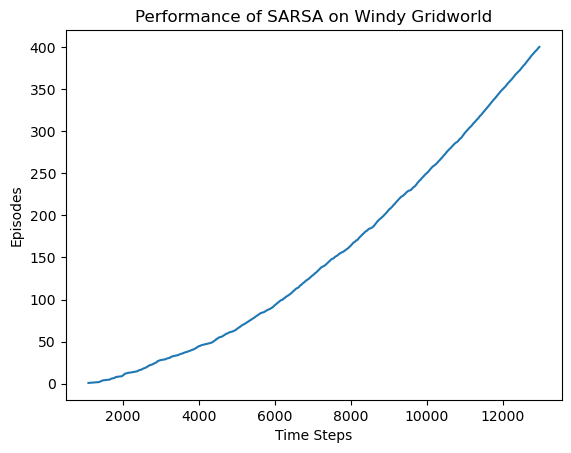

In [8]:
plt.plot(time_steps_sarsa,range(1, len(time_steps_sarsa)+1))
plt.xlabel('Time Steps')
plt.ylabel('Episodes')
plt.title('Performance of SARSA on Windy Gridworld')
plt.show()


In [9]:
# print the estimated optimal policy
policy = np.zeros((7, 10))
v = np.zeros((7, 10))
for i in range(7):
    for j in range(10):
        state = (i,j)
        best_action = np.argmax(Q_sarsa[state])
        policy[i,j] = best_action
        v[i,j] = np.max(Q_sarsa[state])

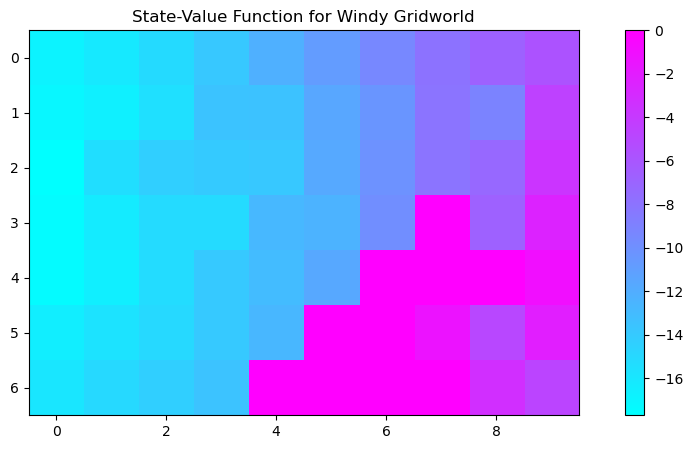

In [10]:
plt.figure(figsize=(12,5))
plt.imshow(v, cmap='cool')
plt.colorbar()
plt.title("State-Value Function for Windy Gridworld")
plt.show()

In [11]:
policy

array([[3., 3., 3., 3., 3., 3., 3., 3., 3., 1.],
       [3., 0., 1., 3., 0., 3., 1., 3., 2., 1.],
       [3., 3., 3., 3., 3., 3., 3., 1., 3., 1.],
       [3., 3., 0., 0., 3., 3., 3., 0., 3., 1.],
       [1., 3., 3., 3., 0., 3., 0., 1., 2., 2.],
       [3., 3., 2., 3., 3., 0., 0., 1., 3., 0.],
       [3., 0., 3., 3., 0., 0., 0., 0., 2., 2.]])

In [12]:
state = env.reset()
policy_plot = np.zeros((7, 10))
steps = 0
while True:
    action = np.argmax(Q_sarsa[state])
    next_state, reward, done = env.step(action)
    print(state, action, next_state, reward, done)
    state = next_state
    steps += 1
    if done:
        print("Goal reached!")
        print(f"Total steps taken: {steps}")
        break

(3, 0) 3 (np.int64(3), 1) -1 False
(np.int64(3), 1) 3 (np.int64(3), 2) -1 False
(np.int64(3), 2) 0 (np.int64(2), 2) -1 False
(np.int64(2), 2) 3 (np.int64(2), 3) -1 False
(np.int64(2), 3) 3 (np.int64(1), 4) -1 False
(np.int64(1), 4) 0 (np.int64(0), 4) -1 False
(np.int64(0), 4) 3 (np.int64(0), 5) -1 False
(np.int64(0), 5) 3 (np.int64(0), 6) -1 False
(np.int64(0), 6) 3 (np.int64(0), 7) -1 False
(np.int64(0), 7) 3 (np.int64(0), 8) -1 False
(np.int64(0), 8) 3 (np.int64(0), 9) -1 False
(np.int64(0), 9) 1 (np.int64(1), 9) -1 False
(np.int64(1), 9) 1 (np.int64(2), 9) -1 False
(np.int64(2), 9) 1 (np.int64(3), 9) -1 False
(np.int64(3), 9) 1 (np.int64(4), 9) -1 False
(np.int64(4), 9) 2 (np.int64(4), 8) -1 False
(np.int64(4), 8) 2 (np.int64(3), 7) 0 True
Goal reached!
Total steps taken: 17


In [13]:
class WindyGridworldAdvanced:
    def __init__(self, stochastic_wind=False):
        self.stochastic_wind = stochastic_wind
        self.grid = np.zeros((7, 10))
        self.wind = np.array([0, 0, 0, 1, 1, 1, 2, 2, 1, 0])
        self.actions = [0, 1, 2, 3, 4, 5, 6, 7, 8]  # up, down, left, right, upper left, upper right, lower left, lower right, no action
        self.action_space = len(self.actions)
        self.start = (3, 0)
        self.goal = (3, 7)
        self.state = self.reset()
    
    def step(self, action):
        #up:0, down:1, left:2, right:3
        #upper left:4, upper right:5, lower left:6, lower right:7, no action:8
        x,y = self.state
        wind_effect = self.wind[y] 

        if action==0:#up
            x = max(0,x-1)
        elif action==1:#down
            x = min(6,x+1)
        elif action==2:#left
            y = max(0, y-1)
        elif action==3:#right
            y = min(9,y+1)
        elif action==4:#upper left
            x = max(0,x-1)
            y = max(0, y-1)
        elif action==5:#upper right
            x = max(0,x-1)
            y = min(9,y+1)
        elif action==6:#lower left
            x = min(6,x+1)
            y = max(0, y-1)
        elif action==7:#lower right
            x = min(6,x+1)
            y = min(9,y+1)
        else:#no action
            pass
        
        #wind effect
        x = x- wind_effect
        x = np.clip(x,0, 6)
        self.state = x,y

        #stochastic wind effect
        if self.stochastic_wind:
            wind_variation = np.random.choice([-1, 0, 1])  # Wind can vary by -1, 0, or +1
            x = self.state[0] - wind_variation
            x = np.clip(x, 0, 6)
            self.state = (x, self.state[1])

        return self.state, self.reward(), self.state==self.goal
    
    def reset(self):
        self.state = self.start
        return self.state
    
    def reward(self):
        return 0 if self.state==self.goal else -1

In [14]:
env = WindyGridworldAdvanced()
Q_sarsa_advance, time_steps_sarsa_advance = sarsa(env, 300, epsilon=0.1, alpha=0.5)

Episode 300/300

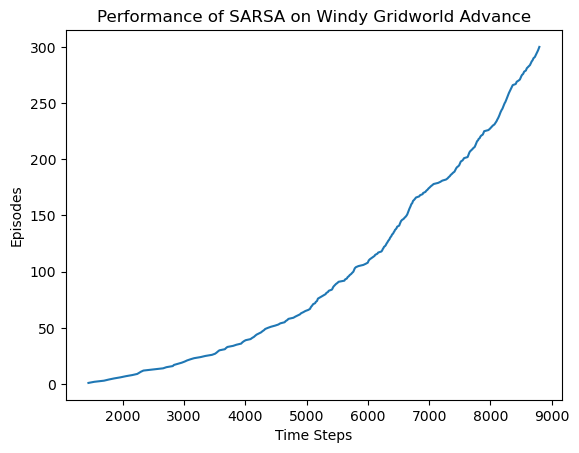

In [15]:
plt.plot(time_steps_sarsa_advance,range(1, len(time_steps_sarsa_advance)+1))
plt.xlabel('Time Steps')
plt.ylabel('Episodes')
plt.title('Performance of SARSA on Windy Gridworld Advance')
plt.show()


In [16]:
# print the estimated optimal policy
policy_advance = np.zeros((7, 10))
v_advance = np.zeros((7, 10))
for i in range(7):
    for j in range(10):
        state = (i,j)
        best_action = np.argmax(Q_sarsa_advance[state])
        policy_advance[i,j] = best_action
        v_advance[i,j] = np.max(Q_sarsa_advance[state])

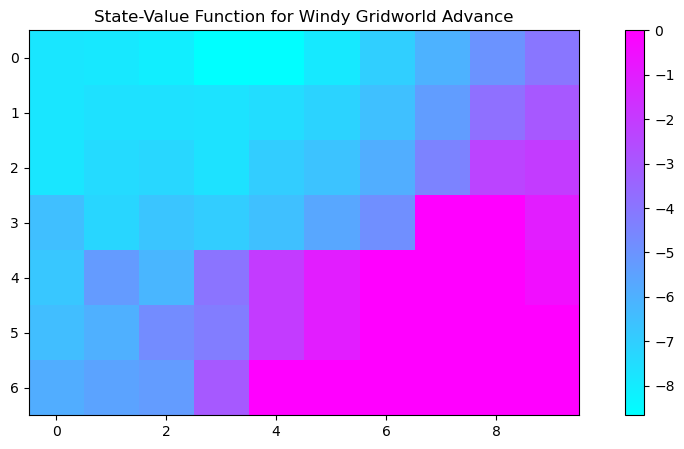

In [17]:
plt.figure(figsize=(12,5))
plt.imshow(v_advance, cmap='cool')
plt.colorbar()
plt.title("State-Value Function for Windy Gridworld Advance")
plt.show()

In [18]:
policy_advance

array([[0., 7., 3., 2., 8., 5., 7., 3., 5., 1.],
       [3., 8., 1., 5., 5., 0., 6., 3., 3., 7.],
       [0., 7., 5., 2., 8., 7., 7., 8., 7., 1.],
       [7., 3., 1., 6., 7., 1., 3., 0., 6., 2.],
       [7., 7., 3., 7., 7., 7., 7., 1., 2., 4.],
       [6., 7., 7., 3., 7., 7., 3., 0., 3., 3.],
       [3., 3., 8., 3., 0., 0., 0., 0., 0., 1.]])

In [19]:
state = env.reset()
policy_plot = np.zeros((7, 10))
steps = 0
while True:
    action = np.argmax(Q_sarsa_advance[state])
    next_state, reward, done = env.step(action)
    print(state, action, next_state, reward, done)
    state = next_state
    steps += 1
    if done:
        print("Goal reached!")
        print(f"Total steps taken: {steps}")
        break

(3, 0) 7 (np.int64(4), 1) -1 False
(np.int64(4), 1) 7 (np.int64(5), 2) -1 False
(np.int64(5), 2) 7 (np.int64(6), 3) -1 False
(np.int64(6), 3) 3 (np.int64(5), 4) -1 False
(np.int64(5), 4) 7 (np.int64(5), 5) -1 False
(np.int64(5), 5) 7 (np.int64(5), 6) -1 False
(np.int64(5), 6) 3 (np.int64(3), 7) 0 True
Goal reached!
Total steps taken: 7


In [20]:
env = WindyGridworldAdvanced(stochastic_wind=True)
Q_sarsa_advance_stochastic_wind, time_steps_sarsa_advance_stochastic_wind = sarsa(env, 1000, epsilon=0.1, alpha=0.5)

Episode 1000/1000

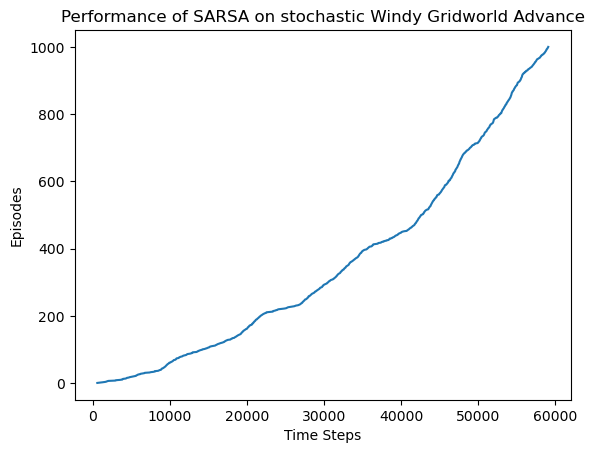

In [21]:
plt.plot(time_steps_sarsa_advance_stochastic_wind,range(1, len(time_steps_sarsa_advance_stochastic_wind)+1))
plt.xlabel('Time Steps')
plt.ylabel('Episodes')
plt.title('Performance of SARSA on stochastic Windy Gridworld Advance')
plt.show()


In [22]:
# print the estimated optimal policy
policy_advance_stochastic_wind = np.zeros((7, 10))
v_advance_stochastic_wind = np.zeros((7, 10))
for i in range(7):
    for j in range(10):
        state = (i,j)
        best_action = np.argmax(Q_sarsa_advance_stochastic_wind[state])
        policy_advance_stochastic_wind[i,j] = best_action
        v_advance_stochastic_wind[i,j] = np.max(Q_sarsa_advance_stochastic_wind[state])

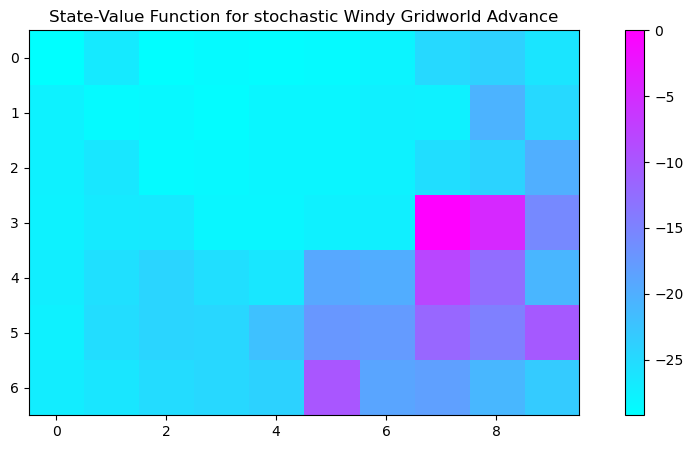

In [23]:
plt.figure(figsize=(12,5))
plt.imshow(v_advance_stochastic_wind, cmap='cool')
plt.colorbar()
plt.title("State-Value Function for stochastic Windy Gridworld Advance")
plt.show()

In [24]:
policy_advance_stochastic_wind

array([[7., 7., 3., 5., 6., 3., 7., 5., 0., 2.],
       [7., 0., 4., 0., 7., 3., 7., 3., 7., 6.],
       [7., 7., 7., 5., 6., 1., 1., 3., 7., 1.],
       [3., 7., 1., 6., 8., 1., 5., 0., 6., 6.],
       [7., 7., 7., 7., 7., 3., 7., 1., 4., 0.],
       [6., 7., 7., 7., 7., 1., 7., 7., 0., 4.],
       [3., 3., 5., 7., 6., 3., 4., 7., 6., 4.]])

In [25]:
state = env.reset()
policy_plot = np.zeros((7, 10))
steps = 0
while True:
    action = np.argmax(Q_sarsa_advance_stochastic_wind[state])
    next_state, reward, done = env.step(action)
    print(state, action, next_state, reward, done)
    state = next_state
    steps += 1
    if done:
        print("Goal reached!")
        print(f"Total steps taken: {steps}")
        break

(3, 0) 3 (np.int64(2), 1) -1 False
(np.int64(2), 1) 7 (np.int64(2), 2) -1 False
(np.int64(2), 2) 7 (np.int64(4), 3) -1 False
(np.int64(4), 3) 7 (np.int64(4), 4) -1 False
(np.int64(4), 4) 7 (np.int64(5), 5) -1 False
(np.int64(5), 5) 1 (np.int64(4), 5) -1 False
(np.int64(4), 5) 3 (np.int64(2), 6) -1 False
(np.int64(2), 6) 1 (np.int64(0), 6) -1 False
(np.int64(0), 6) 7 (np.int64(1), 7) -1 False
(np.int64(1), 7) 3 (np.int64(1), 8) -1 False
(np.int64(1), 8) 7 (np.int64(2), 9) -1 False
(np.int64(2), 9) 1 (np.int64(3), 9) -1 False
(np.int64(3), 9) 6 (np.int64(5), 8) -1 False
(np.int64(5), 8) 0 (np.int64(3), 8) -1 False
(np.int64(3), 8) 6 (np.int64(4), 7) -1 False
(np.int64(4), 7) 1 (np.int64(3), 7) 0 True
Goal reached!
Total steps taken: 16
